# CRICAT — ERCOT Capacity-Stress Scenario

**Component:** CRICAT (Climate-Risk Integrated Capacity-Allocation Toolkit)

This notebook builds an ERCOT capacity-stress `capacity_allocation_scenario` from a small set of analyst assumptions, using the transparent CRICAT grid-modeling math: a standard reserve-margin definition and a monotone-decreasing probability-of-stress curve. It then sweeps the assumed capacity to show how reserve margin and stress probability move together.

> **Synthetic data only.** Every dataset used in this notebook is *synthetic illustrative data generated for demonstration*. It is **NOT** real agency data and is **NOT** derived from any proprietary or employer source. The notebook performs no network access and uses only public-style, open-source components.

In [1]:
import sys
from pathlib import Path

# Put the oefaf-platform repository root on sys.path so the platform
# component packages (gea, cricat, sdmac, shared) import cleanly no matter
# what working directory this notebook is executed from.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'sdmac' / 'schema_registry').is_dir():
    if _REPO_ROOT == _REPO_ROOT.parent:
        raise RuntimeError('Could not locate the oefaf-platform repo root.')
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print('repo root located:', _REPO_ROOT.name)

repo root located: oefaf-platform


## 1. Build an ERCOT extreme-heat capacity-stress scenario

`cricat.scenarios.builder.build_scenario` computes the reserve margin and probability of stress and returns a `capacity_allocation_scenario` document. The demand/capacity magnitudes here are synthetic illustrative assumptions only.

In [2]:
import json

from cricat.scenarios.builder import build_scenario

scenario = build_scenario(
    scenario_label='summer_2027_extreme_heat_ercot',
    stress_drivers=['heatwave', 'forced_outage'],
    regions=['ERCOT'],
    time_horizon_hours=24,
    assumed_demand_mw=82_000.0,        # synthetic illustrative peak demand
    assumed_available_capacity_mw=80_500.0,  # synthetic illustrative capacity
)
print(json.dumps(scenario, indent=2))

{
  "scenario_id": "CRICAT-SCN-fb814a53",
  "scenario_label": "summer_2027_extreme_heat_ercot",
  "stress_drivers": [
    "heatwave",
    "forced_outage"
  ],
  "time_horizon_hours": 24,
  "regions": [
    "ERCOT"
  ],
  "assumed_demand_mw": 82000.0,
  "assumed_available_capacity_mw": 80500.0,
  "reserve_margin_pct": -1.83,
  "probability_of_stress": 0.568,
  "data_provenance": [
    "<JING_WEN_TO_FILL: verified public data-provenance URL(s) for this scenario>"
  ]
}


## 2. Read out reserve margin and probability of stress

A negative reserve margin (demand exceeds capacity) drives the stress probability above 0.5.

In [3]:
print(f"scenario_id:            {scenario['scenario_id']}")
print(f"reserve_margin_pct:     {scenario['reserve_margin_pct']:.2f}%")
print(f"probability_of_stress:  {scenario['probability_of_stress']:.3f}")
print(f"stress_drivers:         {scenario['stress_drivers']}")

scenario_id:            CRICAT-SCN-fb814a53
reserve_margin_pct:     -1.83%
probability_of_stress:  0.568
stress_drivers:         ['heatwave', 'forced_outage']


## 3. Confirm the scenario conforms to the registry schema

In [4]:
from shared.utilities.schema_loader import validate_record

ok = validate_record(scenario, 'capacity_allocation_scenario')
print('scenario valid against capacity_allocation_scenario:', ok)

scenario valid against capacity_allocation_scenario: True


## 4. Sweep assumed capacity: reserve margin vs. stress probability

Holding demand fixed and varying assumed available capacity shows the transparent, monotone relationship between reserve margin and probability of stress.

In [5]:
from cricat.grid_modeling.reserve import (
    probability_of_stress,
    reserve_margin_pct,
)

demand_mw = 82_000.0
capacities = [c * 1000.0 for c in range(74, 95)]  # 74,000 .. 94,000 MW
margins = [reserve_margin_pct(demand_mw, c) for c in capacities]
probs = [probability_of_stress(m) for m in margins]

for c, m, p in zip(capacities[::4], margins[::4], probs[::4], strict=True):
    print(f'capacity={c:>8.0f} MW  margin={m:>7.2f}%  P(stress)={p:.3f}')

capacity=   74000 MW  margin=  -9.76%  P(stress)=0.812
capacity=   78000 MW  margin=  -4.88%  P(stress)=0.675
capacity=   82000 MW  margin=   0.00%  P(stress)=0.500
capacity=   86000 MW  margin=   4.88%  P(stress)=0.325
capacity=   90000 MW  margin=   9.76%  P(stress)=0.188
capacity=   94000 MW  margin=  14.63%  P(stress)=0.100


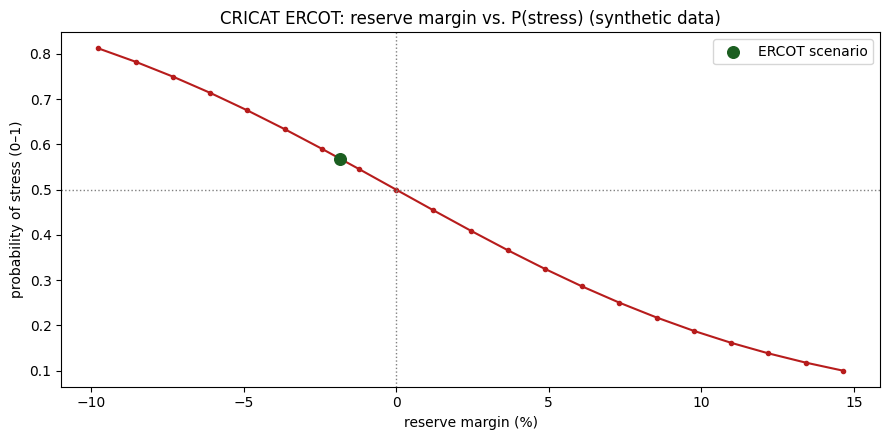

reserve-margin / stress-probability curve rendered (synthetic).


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(margins, probs, color='#b71c1c', marker='o', markersize=3)
ax1.axhline(0.5, color='grey', linestyle=':', linewidth=1)
ax1.axvline(0.0, color='grey', linestyle=':', linewidth=1)
ax1.scatter([scenario['reserve_margin_pct']], [scenario['probability_of_stress']],
            color='#1b5e20', zorder=5, s=70, label='ERCOT scenario')
ax1.set_xlabel('reserve margin (%)')
ax1.set_ylabel('probability of stress (0–1)')
ax1.set_title('CRICAT ERCOT: reserve margin vs. P(stress) (synthetic data)')
ax1.legend()
plt.tight_layout()
plt.show()
print('reserve-margin / stress-probability curve rendered (synthetic).')

---

**Recap.** A `capacity_allocation_scenario` was built from synthetic ERCOT assumptions, its reserve margin and stress probability were read out and schema-validated, and the monotone reserve-margin / stress-probability relationship was demonstrated. All values are synthetic illustrative data; no proprietary or employer content is used.